# MWE 14 - Shape-factor hydraulic conductance comparison

This notebook compares the default circular `generic_poiseuille` conductance with
the new shape-factor-aware Valvatne-Blunt single-phase models.

The experiment has two parts:
1. A controlled synthetic Cartesian network where the only change is the assumed
   conduit cross-sectional shape.
2. A real extracted Ketton rock network to show the impact on absolute permeability
   estimation for image-based data.

Success criteria:
- recover the circular limit for the throat-only shape-factor closure when `G = 1 / (4 pi)`
- quantify the change in throat conductance and `Kabs` for non-circular ducts
- document whether the real extracted example uses the full pore-throat-pore
  conduit model or the throat-only fallback

Fluid-property scope:
- this notebook intentionally keeps viscosity constant so the observed differences are attributable
  to geometry and conduit modeling only, not to pressure-dependent fluid properties

In [21]:
from __future__ import annotations

import sys

import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voids.examples import make_cartesian_mesh_network
from voids.geom.hydraulic import (
    DEFAULT_G_REF,
    SQUARE_G_REF,
    throat_conductance,
)
from voids.io.hdf5 import load_hdf5
from voids.paths import data_path
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)

plt.style.use("seaborn-v0_8-whitegrid")

In [22]:
def equivalent_area_from_inscribed_radius(
    radius: np.ndarray, shape_factor: float
) -> np.ndarray:
    """Return the equivalent duct area for fixed inscribed radius and shape factor."""

    r = np.asarray(radius, dtype=float)
    return r**2 / (4.0 * float(shape_factor))


def equivalent_perimeter_from_area_radius(
    area: np.ndarray, radius: np.ndarray
) -> np.ndarray:
    """Return the perimeter implied by `A = r P / 2`."""

    a = np.asarray(area, dtype=float)
    r = np.asarray(radius, dtype=float)
    return 2.0 * a / np.maximum(r, 1.0e-30)


def apply_equivalent_shape_geometry(
    net, *, pore_shape_factor: float, throat_shape_factor: float
) -> None:
    """Update pore and throat geometry to be consistent with the chosen duct shapes."""

    pore_r = np.asarray(net.pore["radius_inscribed"], dtype=float)
    throat_r = np.asarray(net.throat["radius_inscribed"], dtype=float)

    pore_area = equivalent_area_from_inscribed_radius(pore_r, pore_shape_factor)
    throat_area = equivalent_area_from_inscribed_radius(throat_r, throat_shape_factor)

    net.pore["area"] = pore_area
    net.pore["perimeter"] = equivalent_perimeter_from_area_radius(pore_area, pore_r)
    net.pore["shape_factor"] = np.full(net.Np, float(pore_shape_factor), dtype=float)

    net.throat["area"] = throat_area
    net.throat["perimeter"] = equivalent_perimeter_from_area_radius(
        throat_area, throat_r
    )
    net.throat["shape_factor"] = np.full(
        net.Nt, float(throat_shape_factor), dtype=float
    )
    net.throat["volume"] = throat_area * np.asarray(
        net.throat["core_length"], dtype=float
    )


def run_singlephase_case(
    net, *, axis: str, model: str, viscosity: float, pin: float, pout: float
) -> dict[str, float]:
    """Solve one single-phase case and return a compact metric dictionary."""

    res = solve(
        net,
        fluid=FluidSinglePhase(viscosity=viscosity),
        bc=PressureBC(f"inlet_{axis}min", f"outlet_{axis}max", pin=pin, pout=pout),
        axis=axis,
        options=SinglePhaseOptions(conductance_model=model, solver="direct"),
    )
    g = throat_conductance(net, viscosity=viscosity, model=model)
    return {
        "Q": res.total_flow_rate,
        "k_abs": res.permeability[axis],
        "g_mean": float(np.mean(g)),
        "g_median": float(np.median(g)),
        "g_min": float(np.min(g)),
        "g_max": float(np.max(g)),
    }


def finalize_figure(fig) -> None:
    """Show figures in notebooks and close them in non-interactive script runs."""

    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        plt.close(fig)
    else:
        plt.show()

## Plan

- keep the synthetic topology and inscribed radii fixed
- change only the equivalent duct shape factor `G`
- compare `generic_poiseuille`, `valvatne_blunt_throat`, and `valvatne_blunt`
- then repeat the permeability comparison on the real Ketton extracted network

In [23]:
synthetic_base = make_cartesian_mesh_network(
    (8, 8, 8),
    spacing=1.0,
    pore_radius=0.22,
    throat_radius=0.10,
)

synthetic_shape_cases = {
    "circle": DEFAULT_G_REF,
    "square": SQUARE_G_REF,
    "triangle": 0.03,
}
synthetic_models = (
    "generic_poiseuille",
    "valvatne_blunt_throat",
    "valvatne_blunt",
)

synthetic_rows: list[dict[str, float | str]] = []
for shape_name, g_shape in synthetic_shape_cases.items():
    net_case = synthetic_base.copy()
    apply_equivalent_shape_geometry(
        net_case,
        pore_shape_factor=g_shape,
        throat_shape_factor=g_shape,
    )
    for model in synthetic_models:
        metrics = run_singlephase_case(
            net_case,
            axis="x",
            model=model,
            viscosity=1.0,
            pin=1.0,
            pout=0.0,
        )
        synthetic_rows.append(
            {
                "shape_case": shape_name,
                "shape_factor": g_shape,
                "model": model,
                **metrics,
            }
        )

synthetic_df = pd.DataFrame(synthetic_rows)
synthetic_df

,shape_case,shape_factor,model,Q,k_abs,g_mean,g_median,g_min,g_max
0,circle,0.079577,generic_poiseuille,0.000359,0.000045,0.000039,0.000039,0.000039,0.000039
1,circle,0.079577,valvatne_blunt_throat,0.000359,0.000045,0.000039,0.000039,0.000039,0.000039
2,circle,0.079577,valvatne_blunt,0.000620,0.000078,0.000068,0.000068,0.000068,0.000068
3,square,0.062500,generic_poiseuille,0.000359,0.000045,0.000039,0.000039,0.000039,0.000039
4,square,0.062500,valvatne_blunt_throat,0.000514,0.000064,0.000056,0.000056,0.000056,0.000056
5,square,0.062500,valvatne_blunt,0.000888,0.000111,0.000097,0.000097,0.000097,0.000097
6,triangle,0.030000,generic_poiseuille,0.000359,0.000045,0.000039,0.000039,0.000039,0.000039
7,triangle,0.030000,valvatne_blunt_throat,0.001143,0.000143,0.000125,0.000125,0.000125,0.000125
8,triangle,0.030000,valvatne_blunt,0.001975,0.000247,0.000216,0.000216,0.000216,0.000216


In [24]:
synthetic_pivot = synthetic_df.pivot(
    index="shape_case", columns="model", values="k_abs"
)
synthetic_pivot["valvatne_throat_vs_generic"] = (
    synthetic_pivot["valvatne_blunt_throat"] / synthetic_pivot["generic_poiseuille"]
)
synthetic_pivot["valvatne_full_vs_generic"] = (
    synthetic_pivot["valvatne_blunt"] / synthetic_pivot["generic_poiseuille"]
)
synthetic_pivot

model,generic_poiseuille,valvatne_blunt,valvatne_blunt_throat,valvatne_throat_vs_generic,valvatne_full_vs_generic
shape_case,,,,,
circle,0.000045,0.000078,0.000045,1.000000,1.727764
square,0.000045,0.000111,0.000064,1.431885,2.473959
triangle,0.000045,0.000247,0.000143,3.183099,5.499642


In the circular limit, `valvatne_blunt_throat` collapses to the generic Poiseuille
result. The full `valvatne_blunt` model still differs because it resolves the
pore1-throat-pore2 conduit in series instead of treating the whole center-to-center
distance as one cylindrical throat. For square and triangular ducts, the additional
shift also includes the non-circular hydraulic prefactor and the larger equivalent
cross-sectional area at fixed inscribed radius.

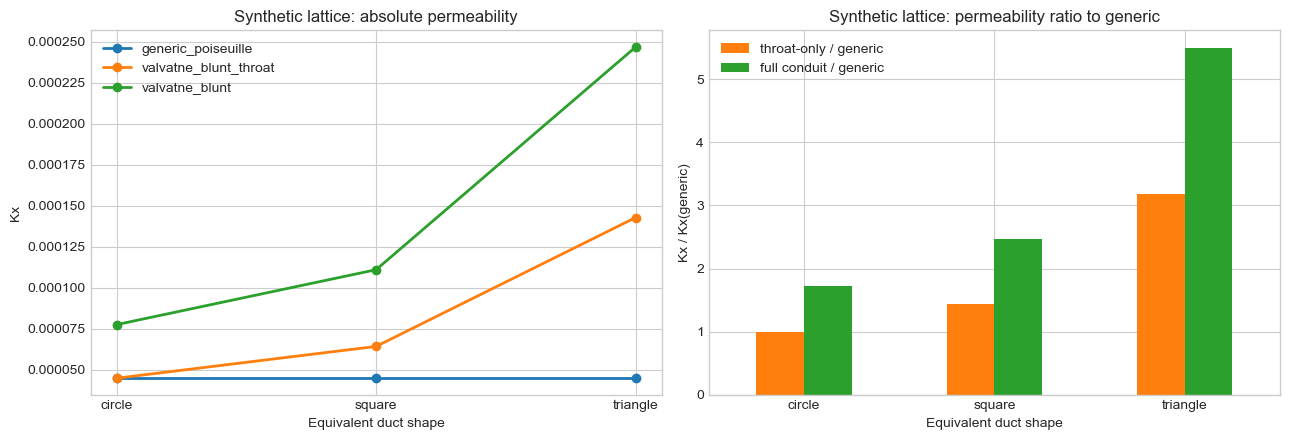

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for model in synthetic_models:
    subset = synthetic_df[synthetic_df["model"] == model]
    axes[0].plot(
        subset["shape_case"],
        subset["k_abs"],
        marker="o",
        linewidth=2,
        label=model,
    )

axes[0].set_title("Synthetic lattice: absolute permeability")
axes[0].set_xlabel("Equivalent duct shape")
axes[0].set_ylabel("Kx")
axes[0].legend()

ratio_cols = ["valvatne_throat_vs_generic", "valvatne_full_vs_generic"]
synthetic_pivot[ratio_cols].plot(
    kind="bar",
    ax=axes[1],
    rot=0,
    color=["tab:orange", "tab:green"],
)
axes[1].set_title("Synthetic lattice: permeability ratio to generic")
axes[1].set_xlabel("Equivalent duct shape")
axes[1].set_ylabel("Kx / Kx(generic)")
axes[1].legend(["throat-only / generic", "full conduit / generic"])

plt.tight_layout()
finalize_figure(fig)

## Real extracted Ketton network

This is the shipped longest-axis-spanning network extracted from the segmented
Ketton image. It is small enough to solve quickly and representative enough to
show the practical change in `Kabs`.

In [26]:
ketton_path = data_path() / "ketton_network_zspanning_voids.h5"
ketton = load_hdf5(ketton_path)

print("File:", ketton_path)
print("Np, Nt =", ketton.Np, ketton.Nt)
print("throat keys =", sorted(ketton.throat.keys()))
print("pore keys =", sorted(ketton.pore.keys()))
print(
    "has conduit sub-lengths =",
    all(
        name in ketton.throat
        for name in ("pore1_length", "core_length", "pore2_length")
    ),
)

File: /Users/dtvolpatto/Work/voids/examples/data/ketton_network_zspanning_voids.h5
Np, Nt = 140 211
throat keys = ['area', 'diameter_equivalent', 'diameter_inscribed', 'direct_length', 'global_peak', 'length', 'perimeter', 'phases', 'radius_inscribed', 'shape_factor', 'volume']
pore keys = ['area', 'diameter_equivalent', 'diameter_inscribed', 'extended_diameter', 'geometric_centroid', 'global_peak', 'local_peak', 'phase', 'radius_inscribed', 'region_label', 'region_volume', 'surface_area', 'volume']
has conduit sub-lengths = False


In [27]:
rock_models = (
    "generic_poiseuille",
    "valvatne_blunt_throat",
    "valvatne_blunt",
)
rock_rows: list[dict[str, float | str]] = []
rock_conductance: dict[str, np.ndarray] = {}

for model in rock_models:
    rock_conductance[model] = throat_conductance(ketton, viscosity=1.0e-3, model=model)
    metrics = run_singlephase_case(
        ketton,
        axis="z",
        model=model,
        viscosity=1.0e-3,
        pin=2.0e5,
        pout=1.0e5,
    )
    rock_rows.append({"model": model, **metrics})

rock_df = pd.DataFrame(rock_rows)
rock_df

,model,Q,k_abs,g_mean,g_median,g_min,g_max
0,generic_poiseuille,1.331547e-07,4.235422e-12,5.093501e-12,8.214590e-14,3.609531e-17,1.287341e-10
1,valvatne_blunt_throat,3.607278e-07,1.147413e-11,8.990595e-12,1.599748e-13,6.809057e-17,2.623063e-10
2,valvatne_blunt,3.607278e-07,1.147413e-11,8.990595e-12,1.599748e-13,6.809057e-17,2.623063e-10


In [28]:
ratio_throat = np.divide(
    rock_conductance["valvatne_blunt"],
    rock_conductance["generic_poiseuille"],
    out=np.full_like(rock_conductance["generic_poiseuille"], np.nan, dtype=float),
    where=rock_conductance["generic_poiseuille"] > 0,
)

ratio_summary = (
    pd.Series(ratio_throat)
    .quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    .rename("g_valvatne_over_g_generic")
)
ratio_summary

0.05    1.007310
0.25    1.284929
0.50    1.832741
0.75    2.608757
0.95    3.950829
Name: g_valvatne_over_g_generic, dtype: float64

In [29]:
full_equals_throat_only = np.allclose(
    rock_conductance["valvatne_blunt"],
    rock_conductance["valvatne_blunt_throat"],
)
print(
    "valvatne_blunt == valvatne_blunt_throat on this dataset:", full_equals_throat_only
)

valvatne_blunt == valvatne_blunt_throat on this dataset: True


The shipped Ketton example does not contain pore-throat-pore conduit-length
decomposition, so `valvatne_blunt` collapses to the throat-only shape-factor
variant here. The difference relative to `generic_poiseuille` is therefore purely
the effect of the non-circular single-phase conductance closure.

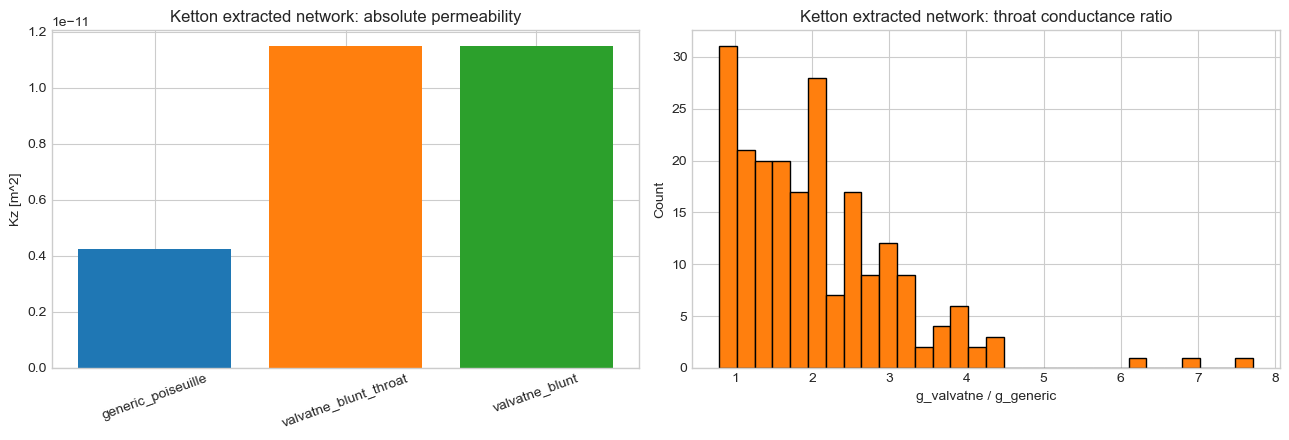

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    rock_df["model"], rock_df["k_abs"], color=["tab:blue", "tab:orange", "tab:green"]
)
axes[0].set_title("Ketton extracted network: absolute permeability")
axes[0].set_ylabel("Kz [m^2]")
axes[0].tick_params(axis="x", rotation=20)

axes[1].hist(
    ratio_throat[np.isfinite(ratio_throat)],
    bins=30,
    color="tab:orange",
    edgecolor="black",
)
axes[1].set_title("Ketton extracted network: throat conductance ratio")
axes[1].set_xlabel("g_valvatne / g_generic")
axes[1].set_ylabel("Count")

plt.tight_layout()
finalize_figure(fig)

## Findings

- The circular case recovers the generic Poiseuille result, as expected.
- For non-circular ducts, the shape-aware model changes both throat conductance
  statistics and absolute permeability.
- On the shipped Ketton example, the current extraction does not provide conduit
  sub-lengths, so the practical improvement comes from the throat-only shape-factor
  closure. Once conduit decomposition is available in extracted data, the full
  `valvatne_blunt` model will additionally account for pore-body resistance.